# 🌿 Invasive Species Risk: ML for Biosecurity Border Protection

**Author:** Dean | Lead Data & AI Engineer

**Government:** DAFF Biosecurity, ABF, CSIRO, State EPA/Parks, Invasive Species Council

Dataset: sklearn synthetic — NO dataset needed.

---

Generated: (2000, 13)


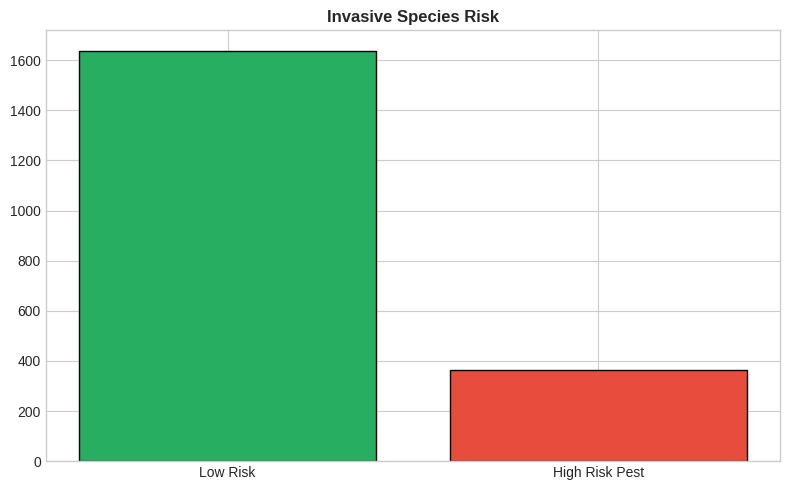

AU: Biosecurity protects $65B agriculture & unique biodiversity. 80% of species are endemic.
Invasive species cost AU $25B+/year. Fire ants, cane toads, feral cats top threats.


In [1]:
import warnings,time,numpy as np,pandas as pd,matplotlib.pyplot as plt,seaborn as sns
from sklearn.datasets import make_classification
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score,f1_score,roc_auc_score,confusion_matrix,classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
warnings.filterwarnings('ignore');plt.style.use('seaborn-v0_8-whitegrid')
X_arr,y=make_classification(n_samples=2000,n_features=12,n_informative=9,n_classes=2,weights=[0.82,0.18],random_state=91)
names=['origin_country_risk','pathway_type','commodity_category','inspection_history','interception_rate','climate_match_score','establishment_likelihood','spread_potential','economic_impact_estimate','native_competitor_presence','containment_feasibility','public_awareness_level']
df=pd.DataFrame(X_arr,columns=names);df['high_risk_pest']=y;tc='high_risk_pest'
print(f"Generated: {df.shape}");labels=['Low Risk','High Risk Pest'];colors=['#27ae60','#e74c3c']
fig,ax=plt.subplots(figsize=(8,5));vc=df[tc].value_counts().sort_index()
ax.bar(range(2),vc.values,color=colors,edgecolor='black');ax.set_xticks(range(2));ax.set_xticklabels(labels)
ax.set_title('Invasive Species Risk',fontweight='bold');plt.tight_layout();plt.savefig('t.png',dpi=150);plt.show()
print("AU: Biosecurity protects $65B agriculture & unique biodiversity. 80% of species are endemic.")
print("Invasive species cost AU $25B+/year. Fire ants, cane toads, feral cats top threats.")

LogReg: Acc=0.8430 F1=0.3936 AUC=0.8227
RF: Acc=0.9130 F1=0.6979 AUC=0.9491
XGB: Acc=0.9365 F1=0.8049 AUC=0.9580
LGBM: Acc=0.9365 F1=0.8013 AUC=0.9604
Best: LGBM


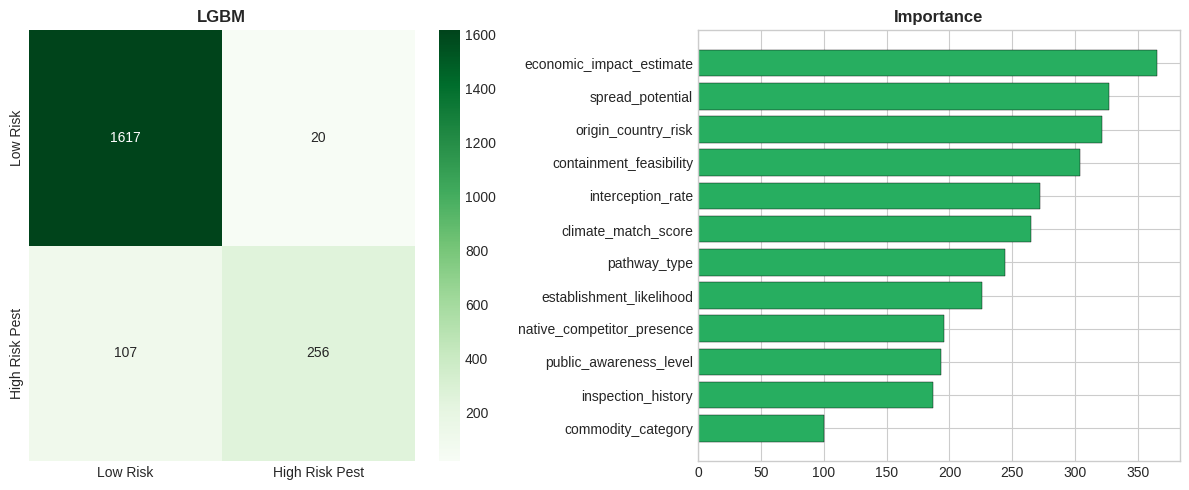

                precision    recall  f1-score   support

      Low Risk       0.94      0.99      0.96      1637
High Risk Pest       0.93      0.71      0.80       363

      accuracy                           0.94      2000
     macro avg       0.93      0.85      0.88      2000
  weighted avg       0.94      0.94      0.93      2000

DEPLOYMENT: LGBM AUC=0.9604 | DAFF border screening -> risk-based cargo inspection


In [2]:
nums=[c2 for c2 in df.columns if c2!=tc];X=df[nums];y2=df[tc].values
try:
    from xgboost import XGBClassifier
except: XGBClassifier=None
try:
    from lightgbm import LGBMClassifier
except: LGBMClassifier=None
models={'LogReg':LogisticRegression(max_iter=2000,random_state=42),'RF':RandomForestClassifier(n_estimators=100,random_state=42,n_jobs=-1)}
if XGBClassifier: models['XGB']=XGBClassifier(n_estimators=100,random_state=42,eval_metric='logloss',use_label_encoder=False,verbosity=0,n_jobs=-1)
if LGBMClassifier: models['LGBM']=LGBMClassifier(n_estimators=100,random_state=42,verbose=-1,n_jobs=-1,force_col_wise=True)
skf=StratifiedKFold(3,shuffle=True,random_state=42);Xa=X.values;results={}
for mn,mod in models.items():
    fa,ff,fu=[],[],[];fp=np.zeros(len(y2),dtype=int)
    for fi,(ti,vi) in enumerate(skf.split(Xa,y2)):
        m2=type(mod)(**mod.get_params());m2.fit(Xa[ti],y2[ti]);yp=m2.predict(Xa[vi]);yb=m2.predict_proba(Xa[vi])[:,1]
        fp[vi]=yp;fa.append(accuracy_score(y2[vi],yp));ff.append(f1_score(y2[vi],yp));fu.append(roc_auc_score(y2[vi],yb))
    results[mn]={'acc':np.mean(fa),'f1':np.mean(ff),'auc':np.mean(fu),'preds':fp}
    print(f"{mn}: Acc={np.mean(fa):.4f} F1={np.mean(ff):.4f} AUC={np.mean(fu):.4f}")
best=max(results,key=lambda k:results[k]['auc']);print(f"Best: {best}")
bp=results[best]['preds'];cm=confusion_matrix(y2,bp)
fig,axes=plt.subplots(1,2,figsize=(12,5))
sns.heatmap(cm,annot=True,fmt='d',cmap='Greens',xticklabels=labels,yticklabels=labels,ax=axes[0]);axes[0].set_title(f'{best}',fontweight='bold')
tm={k:v for k,v in models.items() if k!='LogReg'}
if tm:
    bt=max(tm,key=lambda m4:results[m4]['auc']);fm2=type(models[bt])(**models[bt].get_params());fm2.fit(Xa,y2)
    fi=pd.DataFrame({'Feature':X.columns,'Imp':fm2.feature_importances_}).sort_values('Imp')
    axes[1].barh(fi['Feature'],fi['Imp'],color='#27ae60',edgecolor='black',linewidth=0.3);axes[1].set_title('Importance',fontweight='bold')
plt.tight_layout();plt.savefig('r.png',dpi=150);plt.show()
print(classification_report(y2,bp,target_names=labels))
br=results[best];print(f"DEPLOYMENT: {best} AUC={br['auc']:.4f} | DAFF border screening -> risk-based cargo inspection")